# Phân tích độc lập giữa các nhãn ACS: OMI, STEMI, NSTEMI, UA, AMI

**Dự án ACS-ECG-AI (Vinmec)**

## Mục đích

`train.csv` gán **5 cột nhị phân riêng biệt** cho mỗi bản ghi ECG: `AMI`, `OMI`, `STEMI`, `NSTEMI`,
`UA`. Trước khi coi đây là bài toán phân loại **đa lớp** (multi-class — mỗi ca chỉ thuộc đúng một
lớp, dùng softmax một đầu ra) hay **đa nhãn** (multi-label — mỗi ca có thể mang nhiều nhãn cùng lúc,
mỗi nhãn một đầu ra sigmoid độc lập), cần trả lời một câu hỏi thực nghiệm: **các nhãn này có loại trừ
lẫn nhau (độc lập, không chồng lấn) hay không?**

Notebook này **chỉ đọc `CSV/train.csv`** (không cần tín hiệu ECG, không train model) và:

1. Đếm số nhãn dương trên mỗi bản ghi — nếu phần lớn bản ghi có ≥2 nhãn dương, đa lớp
   mutually-exclusive sai ngay từ định nghĩa dữ liệu.
2. Dựng ma trận đồng xuất hiện (co-occurrence) và tỷ lệ chồng lấn có điều kiện giữa từng cặp nhãn.
3. Kiểm định thống kê (chi-square + hệ số Cramér's V) cho từng cặp — chồng lấn có ý nghĩa thống kê
   hay chỉ là nhiễu ngẫu nhiên, và mạnh tới mức nào.
4. Liệt kê các tổ hợp nhãn thực tế xuất hiện nhiều nhất.
5. Kết luận: dùng đa lớp hay đa nhãn.

> Notebook tự chứa, chạy được trên **Google Colab** lẫn máy cá nhân — giống các notebook khác trong
> repo, nhưng nhẹ hơn nhiều vì chỉ cần một file CSV, không cần tải/giải nén 59.867 file tín hiệu ECG.

## 1. Cài thư viện

In [1]:
import importlib.util
import subprocess
import sys

for _pkg in ["pandas", "numpy", "matplotlib", "seaborn", "scipy"]:
    if importlib.util.find_spec(_pkg) is None:
        print(f"Đang cài {_pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option("display.width", 200)
sns.set_style("whitegrid")
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.3 | numpy 2.1.3


## 2. Cấu hình đường dẫn

Chỉ cần đúng một file: `CSV/train.csv`. Trên Colab, notebook lấy riêng file này ra khỏi
`datasets.zip` (không giải nén toàn bộ ~2,4 GB / 59.867 file như các notebook train model) nên bước
này chỉ mất vài giây thay vì vài phút.

In [2]:
import zipfile
from pathlib import Path

try:
    IS_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:      # máy không có gói "google" nào -> chắc chắn không phải Colab
    IS_COLAB = False

if IS_COLAB:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")   # <<< SỬA nếu đặt tên khác
    DRIVE_DATA_ZIP = DRIVE_PROJECT / "datasets.zip"             # <<< SỬA nếu tên zip khác
    LOCAL_CSV_DIR = Path("/content/csv")
    LOCAL_CSV_DIR.mkdir(parents=True, exist_ok=True)

    TRAIN_CSV_PATH = LOCAL_CSV_DIR / "train.csv"
    if not TRAIN_CSV_PATH.exists():
        if not DRIVE_DATA_ZIP.exists():
            có_gì = sorted(p.name for p in DRIVE_PROJECT.iterdir())[:40]
            raise FileNotFoundError(f"Không thấy {DRIVE_DATA_ZIP}\nTrong {DRIVE_PROJECT} hiện có: {có_gì}")
        with zipfile.ZipFile(DRIVE_DATA_ZIP) as zf:
            member = next(n for n in zf.namelist() if n.lower().endswith("csv/train.csv"))
            with zf.open(member) as src, open(TRAIN_CSV_PATH, "wb") as dst:
                dst.write(src.read())
    print("train.csv ->", TRAIN_CSV_PATH)
else:
    LOCAL_DATA_ROOT = r"C:\Users\anhquan\Workspace\AI_THUC_CHIEN\VSF_Projects\ECG-experiment\datasets"  # <<< SỬA khi chạy máy cá nhân
    TRAIN_CSV_PATH = Path(LOCAL_DATA_ROOT) / "CSV" / "train.csv"
    assert TRAIN_CSV_PATH.exists(), f"Không thấy {TRAIN_CSV_PATH} -- kiểm tra lại LOCAL_DATA_ROOT"
    print("train.csv ->", TRAIN_CSV_PATH)

Mounted at /content/drive
train.csv -> /content/csv/train.csv


## 3. Đọc dữ liệu và nhãn

5 cột nhãn nhị phân: `AMI` (nhồi máu cơ tim cấp — chẩn đoán lâm sàng chung), `OMI` (tắc mạch vành
cấp xác nhận qua chụp mạch, TIMI 0–1), `STEMI`/`NSTEMI` (phân loại kinh điển theo ST trên ECG), `UA`
(đau thắt ngực không ổn định — thiếu máu cơ tim không nhồi máu).

Sanity check đối chiếu với số ca của paper (đã nhân 0,9 vì `train.csv` chỉ giữ 90%, 10% còn lại là
test ẩn) — giống cách làm ở notebook `06_omi_model_comparison.ipynb`.

In [3]:
LABELS = ["AMI", "OMI", "STEMI", "NSTEMI", "UA"]

df = pd.read_csv(TRAIN_CSV_PATH)
for c in LABELS:
    df[c] = df[c].astype(int)

PAPER_COUNTS = {"STEMI": 1513, "NSTEMI": 1274, "UA": 6197, "AMI": 2933, "OMI": 1274}
TRAIN_FRAC = 0.90
SANITY_TOL = 0.12

print(f"{len(df):,} bản ghi | {df['Patient_id'].nunique():,} bệnh nhân\n")
print(f"{'nhãn':<8}{'đếm được':>11}{'kỳ vọng':>10}{'lệch':>9}")
ok_all = True
for name, full in PAPER_COUNTS.items():
    got = int(df[name].sum())
    exp = full * TRAIN_FRAC
    delta = (got - exp) / exp
    ok_all &= abs(delta) <= SANITY_TOL
    print(f"{name:<8}{got:>11,}{exp:>10,.0f}{delta:>8.1%}   {'OK' if abs(delta) <= SANITY_TOL else 'LỆCH'}")
if not ok_all:
    print("\n!! CẢNH BÁO: số ca lệch quá dung sai so với paper -- kiểm tra lại nguồn dữ liệu.")

display(df[LABELS].sum().rename("số ca dương").to_frame().assign(
    tỷ_lệ=lambda d: (d["số ca dương"] / len(df)).map("{:.2%}".format)))

17,960 bản ghi | 17,018 bệnh nhân

nhãn       đếm được   kỳ vọng     lệch
STEMI         1,442     1,362    5.9%   OK
NSTEMI        1,235     1,147    7.7%   OK
UA            6,213     5,577   11.4%   OK
AMI           2,679     2,640    1.5%   OK
OMI           1,151     1,147    0.4%   OK


,số ca dương,tỷ_lệ
AMI,2679,14.92%
OMI,1151,6.41%
STEMI,1442,8.03%
NSTEMI,1235,6.88%
UA,6213,34.59%


## 4. Số nhãn dương trên mỗi bản ghi

Nếu các nhãn thực sự loại trừ lẫn nhau (mutually exclusive — điều kiện cần để đóng bài toán thành đa
lớp một-đầu-ra), **mọi bản ghi phải có đúng 0 hoặc 1 nhãn dương**. Bảng dưới đếm trực tiếp — đây là
bằng chứng mạnh nhất, không cần kiểm định thống kê gì thêm.

,số bản ghi,% tổng
0,9068,50.49
1,6214,34.60
2,1528,8.51
3,1150,6.40



2,678 / 17,960 bản ghi (14.9%) mang >=2 nhãn cùng lúc.
-> Nếu con số này > 0, các nhãn KHÔNG loại trừ lẫn nhau -- đa lớp mutually-exclusive (softmax 1 đầu ra) không mô tả đúng dữ liệu.


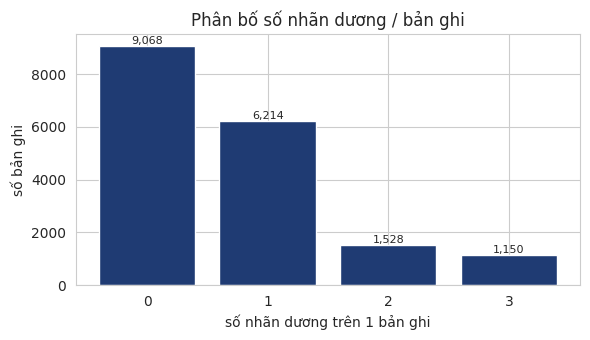

In [4]:
n_pos = df[LABELS].sum(axis=1)
dist = n_pos.value_counts().sort_index()
dist_pct = (dist / len(df) * 100).round(2)

display(pd.DataFrame({"số bản ghi": dist, "% tổng": dist_pct}))

n_multi = int((n_pos >= 2).sum())
print(f"\n{n_multi:,} / {len(df):,} bản ghi ({n_multi / len(df):.1%}) mang >=2 nhãn cùng lúc.")
print("-> Nếu con số này > 0, các nhãn KHÔNG loại trừ lẫn nhau -- đa lớp mutually-exclusive"
      " (softmax 1 đầu ra) không mô tả đúng dữ liệu.")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(dist.index.astype(str), dist.values, color="#1f3b73")
for x, v in zip(dist.index.astype(str), dist.values):
    ax.text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("số nhãn dương trên 1 bản ghi")
ax.set_ylabel("số bản ghi")
ax.set_title("Phân bố số nhãn dương / bản ghi")
plt.tight_layout()
plt.show()

## 5. Ma trận đồng xuất hiện & tỷ lệ chồng lấn

Hai ma trận:

- **Số ca đồng thời dương** ở cả nhãn hàng và nhãn cột (đường chéo = tổng số ca dương của nhãn đó).
- **Tỷ lệ chồng lấn có điều kiện** P(cột=1 | hàng=1) — ví dụ ô (STEMI, OMI) = trong số ca STEMI, bao
  nhiêu % cũng là OMI. Ma trận này **không đối xứng**, đọc theo hàng.

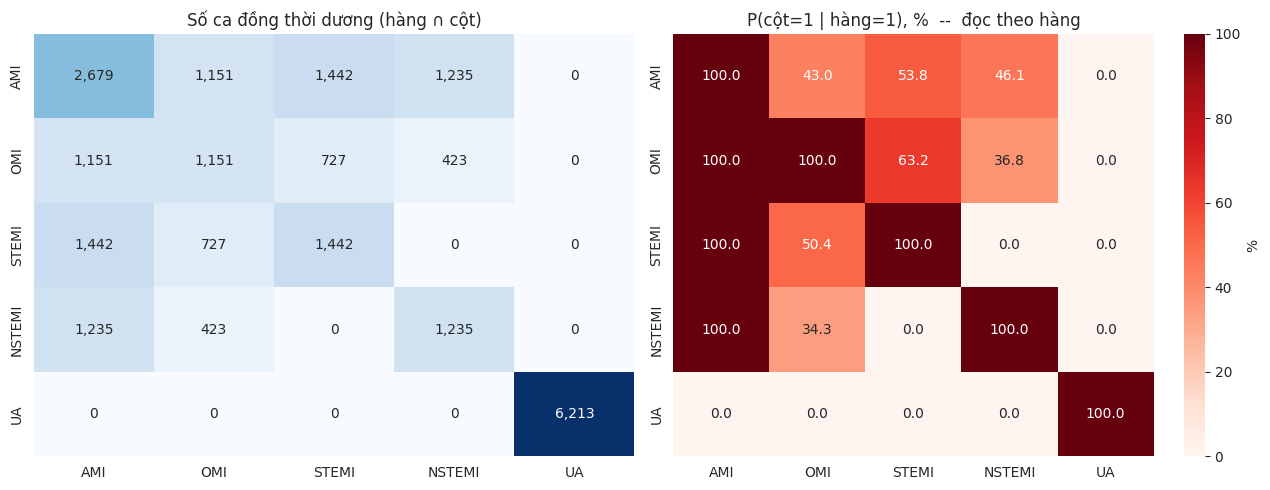

,AMI,OMI,STEMI,NSTEMI,UA
AMI,2679.0,1151.0,1442.0,1235.0,0.0
OMI,1151.0,1151.0,727.0,423.0,0.0
STEMI,1442.0,727.0,1442.0,0.0,0.0
NSTEMI,1235.0,423.0,0.0,1235.0,0.0
UA,0.0,0.0,0.0,0.0,6213.0


In [5]:
co_occur = pd.DataFrame(index=LABELS, columns=LABELS, dtype=int)
overlap_pct = pd.DataFrame(index=LABELS, columns=LABELS, dtype=float)
for a in LABELS:
    for b in LABELS:
        both = int(((df[a] == 1) & (df[b] == 1)).sum())
        co_occur.loc[a, b] = both
        n_a = int((df[a] == 1).sum())
        overlap_pct.loc[a, b] = 100 * both / n_a if n_a else np.nan

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(co_occur.astype(int), annot=True, fmt=",d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Số ca đồng thời dương (hàng ∩ cột)")

sns.heatmap(overlap_pct.astype(float), annot=True, fmt=".1f", cmap="Reds", ax=axes[1],
            cbar_kws={"label": "%"})
axes[1].set_title("P(cột=1 | hàng=1), %  --  đọc theo hàng")
plt.tight_layout()
plt.show()

display(co_occur)

## 6. Kiểm định thống kê độc lập — chi-square & Cramér's V

Với mỗi cặp nhãn, dựng bảng chéo 2×2 rồi chạy chi-square test of independence:

- **H0**: hai nhãn độc lập (không liên quan gì tới nhau).
- **p < 0,05** → bác bỏ H0, tức hai nhãn có liên hệ (không độc lập) có ý nghĩa thống kê.
- **Cramér's V** (= |phi| với bảng 2×2) đo *độ mạnh* của liên hệ, không phụ thuộc cỡ mẫu: ~0 không
  liên hệ, 0,1–0,3 yếu, 0,3–0,5 vừa, >0,5 mạnh. Có thể có ý nghĩa thống kê (p rất nhỏ vì mẫu lớn)
  nhưng độ mạnh vẫn yếu — V mới là con số quyết định chồng lấn có đáng kể trong thực tế hay không.

In [6]:
from itertools import combinations


def cramers_v_and_p(a, b):
    table = pd.crosstab(df[a], df[b])
    chi2, p, dof, _ = chi2_contingency(table, correction=False)
    n = table.values.sum()
    v = np.sqrt(chi2 / n)  # bảng 2x2 -> min(r-1, c-1) = 1
    return chi2, p, v


def strength(v):
    if v < 0.10:
        return "không đáng kể"
    if v < 0.30:
        return "yếu"
    if v < 0.50:
        return "vừa"
    return "mạnh"


rows = []
for a, b in combinations(LABELS, 2):
    chi2, p, v = cramers_v_and_p(a, b)
    rows.append({"cặp nhãn": f"{a} - {b}", "chi2": round(chi2, 1), "p-value": p,
                 "Cramér's V": round(v, 3), "độ mạnh liên hệ": strength(v),
                 "độc lập? (p>=0.05)": "CÓ" if p >= 0.05 else "KHÔNG"})

result = pd.DataFrame(rows).sort_values("Cramér's V", ascending=False).reset_index(drop=True)
display(result)

n_dependent = int((result["độc lập? (p>=0.05)"] == "KHÔNG").sum())
print(f"\n{n_dependent}/{len(result)} cặp nhãn có liên hệ có ý nghĩa thống kê (p<0.05).")

,cặp nhãn,chi2,p-value,Cramér's V,độ mạnh liên hệ,độc lập? (p>=0.05)
0,AMI - STEMI,8943.2,0.000000e+00,0.706,mạnh,KHÔNG
1,AMI - NSTEMI,7564.6,0.000000e+00,0.649,mạnh,KHÔNG
2,AMI - OMI,7014.9,0.000000e+00,0.625,mạnh,KHÔNG
3,OMI - STEMI,5062.5,0.000000e+00,0.531,mạnh,KHÔNG
4,OMI - NSTEMI,1714.0,0.000000e+00,0.309,vừa,KHÔNG
5,AMI - UA,1665.3,0.000000e+00,0.305,vừa,KHÔNG
6,STEMI - UA,829.3,2.352152e-182,0.215,yếu,KHÔNG
7,NSTEMI - UA,701.4,1.464607e-154,0.198,yếu,KHÔNG
8,OMI - UA,650.5,1.783056e-143,0.190,yếu,KHÔNG
9,STEMI - NSTEMI,115.8,5.323869e-27,0.080,không đáng kể,KHÔNG



10/10 cặp nhãn có liên hệ có ý nghĩa thống kê (p<0.05).


## 7. Tổ hợp nhãn thực tế xuất hiện

Bằng chứng trực quan nhất: liệt kê các tổ hợp nhãn (dạng chuỗi, ví dụ `AMI+STEMI+OMI`) xuất hiện
nhiều nhất trong dữ liệu thật.

8 tổ hợp khác nhau xuất hiện trong dữ liệu (tối đa lý thuyết 32).



,số bản ghi,% tổng
(không nhãn nào),9068,50.49
UA,6213,34.59
AMI+NSTEMI,812,4.52
AMI+OMI+STEMI,727,4.05
AMI+STEMI,715,3.98
AMI+OMI+NSTEMI,423,2.36
AMI+OMI,1,0.01
AMI,1,0.01


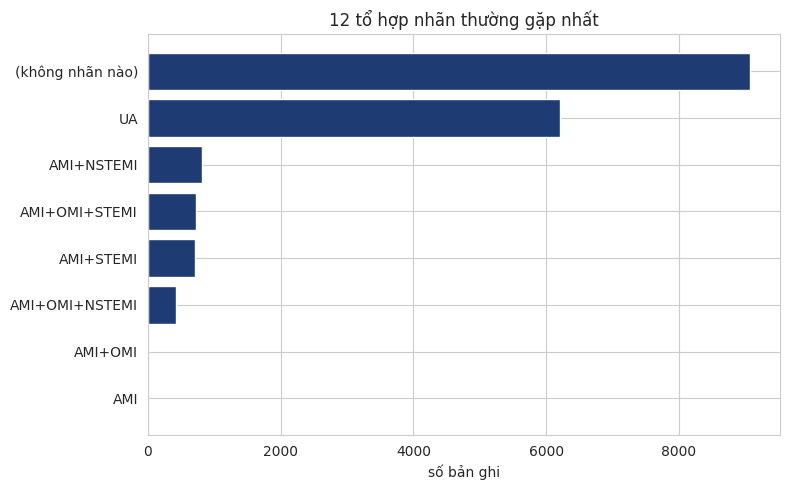

In [7]:
def pattern(row):
    active = [c for c in LABELS if row[c] == 1]
    return "+".join(active) if active else "(không nhãn nào)"


patterns = df.apply(pattern, axis=1)
combo_counts = patterns.value_counts()

n_distinct = len(combo_counts)
n_possible = 2 ** len(LABELS)
print(f"{n_distinct} tổ hợp khác nhau xuất hiện trong dữ liệu (tối đa lý thuyết {n_possible}).\n")

top = combo_counts.head(15).rename("số bản ghi").to_frame()
top["% tổng"] = (top["số bản ghi"] / len(df) * 100).round(2)
display(top)

fig, ax = plt.subplots(figsize=(8, 5))
top_plot = combo_counts.head(12)
ax.barh(top_plot.index[::-1], top_plot.values[::-1], color="#1f3b73")
ax.set_xlabel("số bản ghi")
ax.set_title("12 tổ hợp nhãn thường gặp nhất")
plt.tight_layout()
plt.show()

## 8. Kết luận

In [8]:
strong_pairs = result[result["Cramér's V"] >= 0.30]
print("=" * 70)
print("TÓM TẮT")
print("=" * 70)
print(f"- {n_multi:,}/{len(df):,} bản ghi ({n_multi / len(df):.1%}) mang từ 2 nhãn dương trở lên.")
print(f"- {n_dependent}/{len(result)} cặp nhãn có liên hệ có ý nghĩa thống kê (p<0.05).")
print(f"- {len(strong_pairs)} cặp có liên hệ từ mức 'vừa' trở lên (Cramér's V >= 0.30):")
for _, r in strong_pairs.iterrows():
    v_val = r["Cramér's V"]
    print(f"    {r['cặp nhãn']:<16} V={v_val:.3f} ({r['độ mạnh liên hệ']})")
print(f"- {n_distinct} tổ hợp nhãn khác nhau xuất hiện thực tế (trong tối đa {n_possible} tổ hợp lý thuyết).")

if n_multi > 0:
    print("\n=> Các nhãn KHÔNG loại trừ lẫn nhau. Phân loại đa lớp một-đầu-ra (softmax, ép mỗi ca"
          " chỉ được gán đúng 1 lớp) MÂU THUẪN với chính dữ liệu -- không có cách chọn 1 nhãn 'đúng"
          " nhất' mà không cắt bớt thông tin lâm sàng thật. Nên đóng bài toán thành ĐA NHÃN"
          " (multi-label): mỗi nhãn một đầu ra sigmoid độc lập, đúng như các notebook 01/02/04/06"
          " trong repo đã làm (mỗi nhãn train riêng một model nhị phân) -- không nên gộp 5 nhãn"
          " thành một bài toán phân loại 5 lớp kiểu softmax.")
else:
    print("\n=> Không quan sát thấy ca nào mang >=2 nhãn -- có thể cân nhắc đa lớp. (Kết quả này"
          " bất ngờ so với hiểu biết lâm sàng, nên kiểm tra lại dữ liệu trước khi kết luận.)")

TÓM TẮT
- 2,678/17,960 bản ghi (14.9%) mang từ 2 nhãn dương trở lên.
- 10/10 cặp nhãn có liên hệ có ý nghĩa thống kê (p<0.05).
- 6 cặp có liên hệ từ mức 'vừa' trở lên (Cramér's V >= 0.30):
    AMI - STEMI      V=0.706 (mạnh)
    AMI - NSTEMI     V=0.649 (mạnh)
    AMI - OMI        V=0.625 (mạnh)
    OMI - STEMI      V=0.531 (mạnh)
    OMI - NSTEMI     V=0.309 (vừa)
    AMI - UA         V=0.305 (vừa)
- 8 tổ hợp nhãn khác nhau xuất hiện thực tế (trong tối đa 32 tổ hợp lý thuyết).

=> Các nhãn KHÔNG loại trừ lẫn nhau. Phân loại đa lớp một-đầu-ra (softmax, ép mỗi ca chỉ được gán đúng 1 lớp) MÂU THUẪN với chính dữ liệu -- không có cách chọn 1 nhãn 'đúng nhất' mà không cắt bớt thông tin lâm sàng thật. Nên đóng bài toán thành ĐA NHÃN (multi-label): mỗi nhãn một đầu ra sigmoid độc lập, đúng như các notebook 01/02/04/06 trong repo đã làm (mỗi nhãn train riêng một model nhị phân) -- không nên gộp 5 nhãn thành một bài toán phân loại 5 lớp kiểu softmax.


## Diễn giải lâm sàng nhanh

- **AMI** là nhãn "tổng" (nhồi máu cơ tim cấp nói chung) — về định nghĩa nó thường **bao gồm** cả
  STEMI lẫn NSTEMI, nên chồng lấn cao với hai nhãn này là hợp lý, không phải nhiễu dữ liệu.
- **OMI** cắt ngang STEMI/NSTEMI: tắc mạch hoàn toàn được xác nhận qua chụp mạch, không phải suy ra
  từ hình ảnh ST trên ECG. Notebook `06_omi_model_comparison.ipynb` (mục 4b) đã chỉ ra khoảng 37%
  ca OMI nằm trong nhóm NSTEMI (ST không chênh lên nhưng mạch vẫn tắc hoàn toàn) — đây chính là lý
  do OMI được tách thành bài toán riêng thay vì gộp vào STEMI.
- **UA** (đau thắt ngực không ổn định) theo định nghĩa lâm sàng kinh điển là thiếu máu cơ tim
  **không** nhồi máu — nhìn lại ô UA×AMI/STEMI/NSTEMI/OMI ở mục 5/6: chồng lấn gần 0 xác nhận đúng
  định nghĩa; nếu khác 0 đáng kể thì cần hỏi lại quy trình gán nhãn gốc của bộ dữ liệu.

**Khuyến nghị:** giữ nguyên cách tiếp cận hiện tại của repo — train một model nhị phân riêng cho
từng nhãn cần dự đoán (OMI ở notebook `06`, ACS gộp `STEMI | NSTEMI | UA` ở notebook `04`) thay vì
gộp cả 5 nhãn thành một bài toán phân loại đa lớp (softmax) duy nhất.